# 05. Evaluation and Comparison (Supply vs Demand)

This notebook compares **Developer Supply** (StackOverflow + GitHub) against **Job Market Demand** (Job Postings) using the unified dataset.

## Goals
1.  Load the unified `merged_supply_data.csv`.
2.  Separate data into **Supply** (`stackoverflow`, `github`) and **Demand** (`job`).
3.  Compare the distribution of Domains (e.g., Is there an oversupply of Web Frontend devs?).
4.  Compare the popularity of Technologies within key domains.
5.  Analyze Gaps (Surplus vs Shortage).

In [4]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load Data

In [5]:
# Load Unified Data
df_all = pd.read_csv('data/outputs/Final_Dataset_Label.csv')

# Separate Supply vs Demand
df_supply = df_all[df_all['source_type'] != 'job'].copy()
df_demand = df_all[df_all['source_type'] == 'job'].copy()

print(f"Total Rows: {len(df_all)}")
print(f"Supply Rows (SO + GitHub): {len(df_supply)}")
print(f"Demand Rows (Jobs): {len(df_demand)}")

Total Rows: 15917
Supply Rows (SO + GitHub): 15917
Demand Rows (Jobs): 0


## 2. Preprocessing

Standardize domains if not already consistent.
The generic label is `label`.
We can rename it to `domain` for clarity.

In [6]:
df_supply['domain'] = df_supply['label']
df_demand['domain'] = df_demand['label']

print("Top Supply Domains:")
print(df_supply['domain'].value_counts().head())

print("\nTop Demand Domains:")
print(df_demand['domain'].value_counts().head())

Top Supply Domains:
domain
data_ai            2942
developer tools    2700
web backend        1895
mobile             1840
embedded           1579
Name: count, dtype: int64

Top Demand Domains:
Series([], Name: count, dtype: int64)


## 3. Comparative Complexity: Domain Distribution
Which domains have the highest Supply vs Demand?

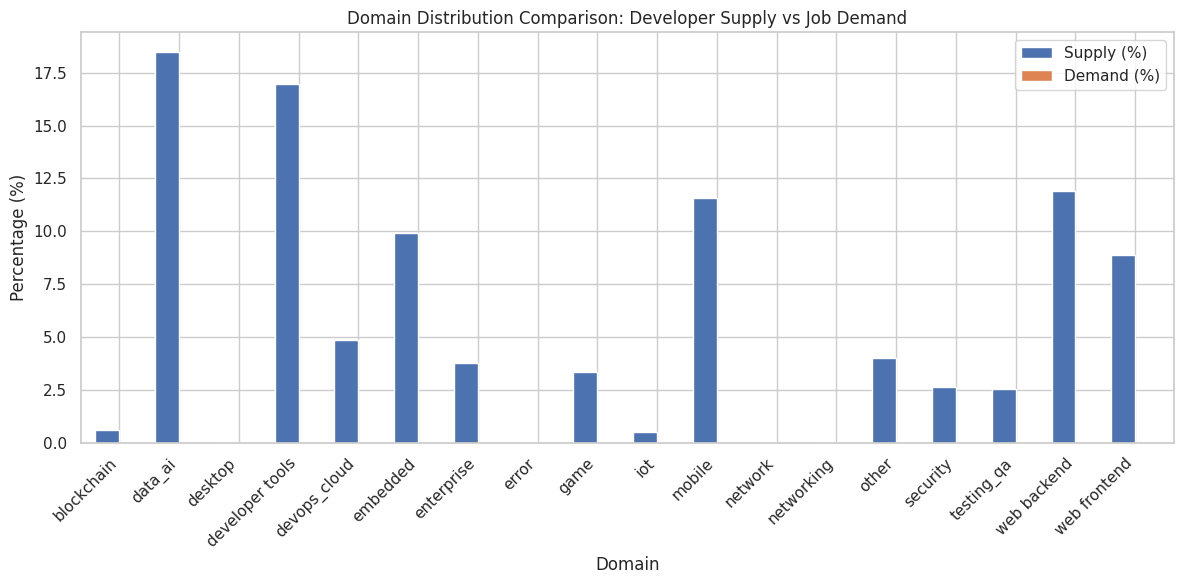

In [7]:
# Calculate Percentages
supply_counts = df_supply['domain'].value_counts(normalize=True) * 100
demand_counts = df_demand['domain'].value_counts(normalize=True) * 100

# Merge into one DataFrame
df_compare = pd.DataFrame({'Supply (%)': supply_counts, 'Demand (%)': demand_counts})
df_compare = df_compare.fillna(0)

# Sort by Demand
df_compare = df_compare.sort_values('Demand (%)', ascending=False)

# Plot
df_compare.plot(kind='bar', figsize=(12, 6), width=0.8)
plt.title('Domain Distribution Comparison: Developer Supply vs Job Demand')
plt.ylabel('Percentage (%)')
plt.xlabel('Domain')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

## 4. Gap Analysis
Where is the biggest mismatch? 
-   **Positive Gap**: Supply > Demand (Oversupply / Competitive)
-   **Negative Gap**: Supply < Demand (Undersupply / Skills Gap)

/tmp/ipykernel_70644/4267711800.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_compare.index, y=df_compare['Gap'], palette=colors)


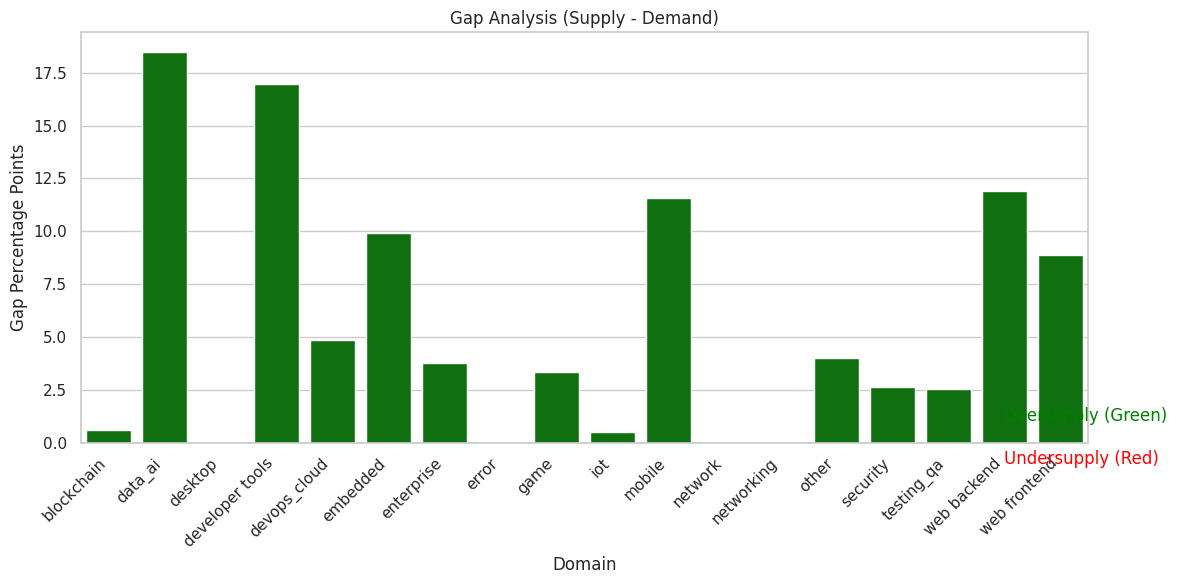

In [8]:
df_compare['Gap'] = df_compare['Supply (%)'] - df_compare['Demand (%)']

plt.figure(figsize=(12, 6))
colors = ['green' if x > 0 else 'red' for x in df_compare['Gap']]
sns.barplot(x=df_compare.index, y=df_compare['Gap'], palette=colors)
plt.title('Gap Analysis (Supply - Demand)')
plt.ylabel('Gap Percentage Points')
plt.xlabel('Domain')
plt.xticks(rotation=45, ha='right')
plt.axhline(0, color='black', linewidth=0.8)
plt.text(len(df_compare)-2, 1, 'Oversupply (Green)', color='green')
plt.text(len(df_compare)-2, -1, 'Undersupply (Red)', color='red')
plt.tight_layout()
plt.show()

## 5. Technology Analysis
Comparing specific languages for a top domain (e.g., 'Web Backend').

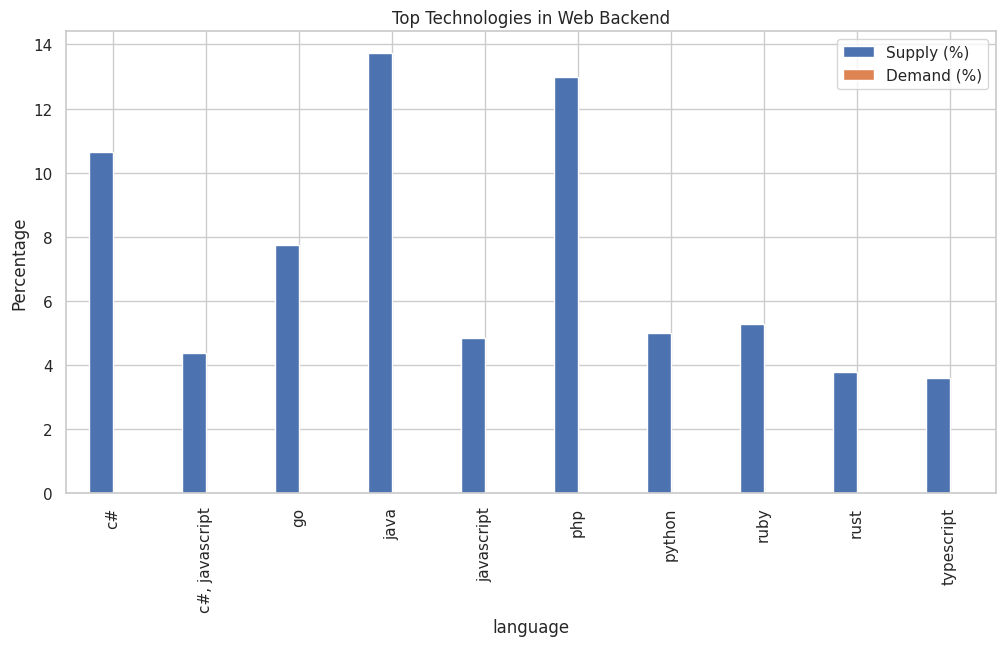

In [9]:
target_domain = 'web backend'

supply_techs = df_supply[df_supply['domain'] == target_domain]['language'].value_counts(normalize=True).head(10) * 100
demand_techs = df_demand[df_demand['domain'] == target_domain]['language'].value_counts(normalize=True).head(10) * 100

tech_compare = pd.DataFrame({'Supply (%)': supply_techs, 'Demand (%)': demand_techs}).fillna(0)
tech_compare.sort_values('Demand (%)', ascending=False).plot(kind='bar', figsize=(12, 6))
plt.title(f'Top Technologies in {target_domain.title()}')
plt.ylabel('Percentage')
plt.show()